# Sentiment analysis for Twitter Text
- Primary step of the Morality based sentimental analysis. Text is tockenized using TF-IDF vectorization and BERT

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score,precision_recall_fscore_support
from sklearn.model_selection import train_test_split,KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim
from transformers import pipeline, BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments,BertPreTrainedModel, BertConfig,BertModel, AutoTokenizer,get_scheduler
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset
import torch
import torch.nn as nn
import requests
import os
import zipfile

In [2]:
# Load dataset from CSV file
file_path = "/content/updated_data.csv"  # Replace with the actual file path
df = pd.read_csv(file_path, encoding = "ISO-8859-1")

# Display the first few rows of the dataset
print(df.head())

  Corpus                                         Tweet Text  Stance Foundation
0    EVM  #EVMs are easy to manipulate . This was demons...      -1   fairness
1    CAA             Congratulations\nCAA  is arrived  #CAA       1    loyalty
2    CAA  My dear Indian muslims we are 35 crores of pop...      -1    loyalty
3    CAA  This guy was part of anti Hindu protests in th...       0   fairness
4    CAA  Woman protester breaks down while speaking to ...       0       care


In [3]:
# Find the number of rows for each unique value in the first column
class_counts = df.iloc[:, 0].value_counts()

# Print the counts for each class
print("Number of rows for each class:")
print(class_counts)

# Print the total number of rows
total_rows = df.shape[0]
print("\nTotal number of rows:", total_rows)

Number of rows for each class:
Corpus
EVM                     904
Animal Sacrifices       882
Anti Conversion Laws    882
LGBTQ                   860
CAA                     855
UCC                     828
Brain Drain             800
Name: count, dtype: int64

Total number of rows: 6011


In [4]:
# Preprocess the data
X = df['Tweet Text']
y = df['Stance']+1

# Bert Model
- The data set is limited(1213 Tweets).
- Model is designed with bert as encoder and fully connected layers as classifier
- Performing K(5 here) fold cross validation for analyzing the performance of the model on the dataset.

In [5]:
# Model Setup
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
class BertForSentimentAnalysis(BertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.bert = BertModel(config)
        self.dropout = nn.Dropout(0.3)  # Reduce dropout

        # self.fc1 = nn.Linear(config.hidden_size, 512)  # One small FC layer
        # self.relu = nn.ReLU()
        self.classifier = nn.Linear(config.hidden_size, 3)  # Output layer

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = outputs.pooler_output  # [CLS] token representation

        x = self.dropout(pooled_output)
        # x = self.fc1(x)
        # x = self.relu(x)

        logits = self.classifier(x)  # Final predictions

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}


In [ ]:
pip install --upgrade transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 98.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.51.1
    Uninstalling transformers-4.51.1:
      Successfully uninstalled transformers-4.51.1


In [ ]:
def k_fold_cross_validation(model, dataset, texts, k=5, batch_size=32, epochs=3, lr=2e-5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    losses, accuracies, precisions, recalls, f1_scores = [], [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold+1}/{k}")

        # Create data samplers
        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)

        train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
        val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)

        # Define training arguments
        training_args = TrainingArguments(
            output_dir=f"./results/fold{fold}",
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=lr,
            weight_decay=0.01,
            logging_dir="./logs",
            logging_steps=100
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=dataset,
            eval_dataset=dataset,  # Full dataset, but using samplers
        )

        # Train & Evaluate
        trainer.train()
        eval_result = trainer.evaluate()
        losses.append(eval_result["eval_loss"])

        # Store predictions & labels
        all_preds, all_labels, misclassified_samples = [], [], []

        model.eval()
        with torch.no_grad():
            for batch_idx, batch in enumerate(val_loader):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs["logits"]
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                # Store misclassified samples
                for i, (pred, true) in enumerate(zip(preds, labels)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[batch_idx * batch_size + i]], true.item(), pred.item()))

        # Compute Metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"🔹 Misclassifications per Class (Actual → Predicted):\n{cm - np.diag(np.diag(cm))}")

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        # Print some misclassified tweets
        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:  # Show first 5 misclassified examples
            print(f"Tweet: \"{text}\" | True: {true} | Predicted: {pred}")

    # Print Final Averages
    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Loss: {np.mean(losses):.4f}")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")



In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
MAX_LEN = 128
bert_train_dataset = CustomDataset(X.tolist(), y.tolist(), bert_tokenizer, MAX_LEN)
#bert_test_dataset = CustomDataset(X_test.tolist(), y_test.tolist(), bert_tokenizer, MAX_LEN)

In [ ]:
bert_labels, bert_preds = [],[]
def evaluate_on_test(model, test_dataset, batch_size=8):
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Store predictions & true labels

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]
            preds = torch.argmax(logits, dim=1)

            bert_preds.extend(preds.cpu().numpy())
            bert_labels.extend(labels.cpu().numpy())



In [ ]:
config = BertConfig.from_pretrained("bert-base-uncased", num_labels=3)
model = BertForSentimentAnalysis.from_pretrained("bert-base-uncased", config=config)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSentimentAnalysis were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSentimentAnalysis(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, 

In [ ]:
text = df["Tweet Text"].tolist()


Fold 1/5


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nlvmadhavca3 (nlvmadhavca3-vasavi-college-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.581800,0.366609
2,0.321900,0.201266
3,0.235200,0.122757


Fold 1 - Accuracy: 0.9609, Precision: 0.9610, Recall: 0.9609, F1-score: 0.9609
🔹 Misclassifications per Class (Actual → Predicted):
[[ 0 15  6]
 [ 9  0  5]
 [ 6  6  0]]


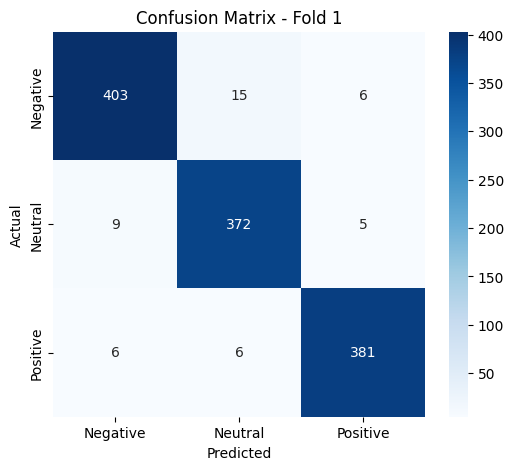


Misclassified Tweets:
Tweet: "LGBT community in India is Anti Hindu Civilization, Anti India and Pro Eslam!
This is their naked truth!" | True: 1 | Predicted: 0
Tweet: "We cannot claim purity by discriminating against others based on religion. CAA is a violation of human dignity. #Injustice" | True: 1 | Predicted: 2
Tweet: "Article 44 of the Constitution envisions a Uniform Civil CodeÃ¢ÂÂit's time to act." | True: 1 | Predicted: 0
Tweet: "Secularism means one law for everyoneÃ¢ÂÂthe UCC will make that a reality." | True: 0 | Predicted: 2
Tweet: "Personal laws must align with constitutional values, but UCC needs caution." | True: 0 | Predicted: 1

Fold 2/5


Epoch,Training Loss,Validation Loss
1,0.195000,0.122705
2,0.098600,0.029687
3,0.048500,0.014416


Fold 2 - Accuracy: 0.9942, Precision: 0.9942, Recall: 0.9942, F1-score: 0.9942
🔹 Misclassifications per Class (Actual → Predicted):
[[0 1 2]
 [0 0 1]
 [1 2 0]]


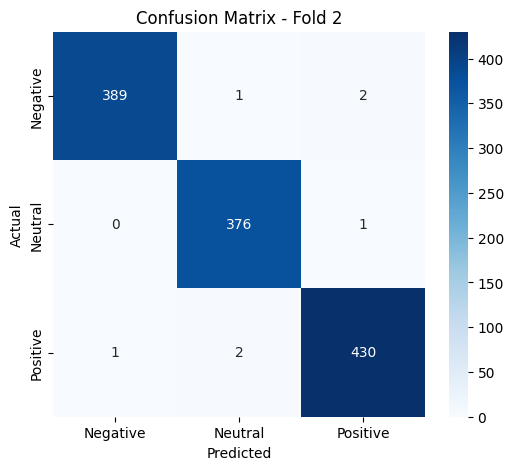


Misclassified Tweets:
Tweet: "Sacrificing animals for religious reasons is a practice that degrades the sanctity of faith. Compassion is the true essence of religion, and no belief should require the pain of an innocent life" | True: 1 | Predicted: 2
Tweet: "EVMs make voting easier for the elderly and disabled. Accessibility matters! #InclusiveDemocracy" | True: 2 | Predicted: 1
Tweet: "Religious conversions should be voluntary, but laws should prevent exploitation. #BalanceIsKey" | True: 2 | Predicted: 0
Tweet: "Justice must be for all, not selective groups. CAA fails this test. #EqualityForAll" | True: 0 | Predicted: 2
Tweet: "Imposing UCC may alienate communities. #SocialHarmonyMatters" | True: 2 | Predicted: 1

Fold 3/5


Epoch,Training Loss,Validation Loss
1,0.045800,0.092127
2,0.032700,0.029500
3,0.032800,0.006806


Fold 3 - Accuracy: 0.9983, Precision: 0.9983, Recall: 0.9983, F1-score: 0.9983
🔹 Misclassifications per Class (Actual → Predicted):
[[0 1 0]
 [1 0 0]
 [0 0 0]]


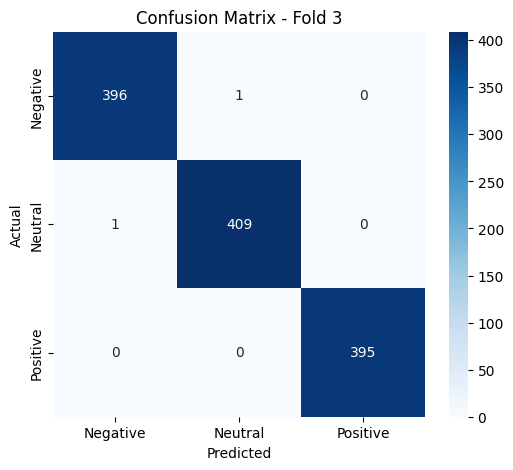


Misclassified Tweets:
Tweet: "We need to maintain the sanctity of traditional marriage.#samesexmarriage #LGBTQ" | True: 0 | Predicted: 1
Tweet: "Anti Conversion Laws laws protect vulnerable communities from forced conversions. #ReligiousSafety" | True: 1 | Predicted: 0

Fold 4/5


Epoch,Training Loss,Validation Loss
1,0.044600,0.110146
2,0.043300,0.029247
3,0.035100,0.012178


Fold 4 - Accuracy: 0.9950, Precision: 0.9950, Recall: 0.9950, F1-score: 0.9950
🔹 Misclassifications per Class (Actual → Predicted):
[[0 0 1]
 [1 0 2]
 [1 1 0]]


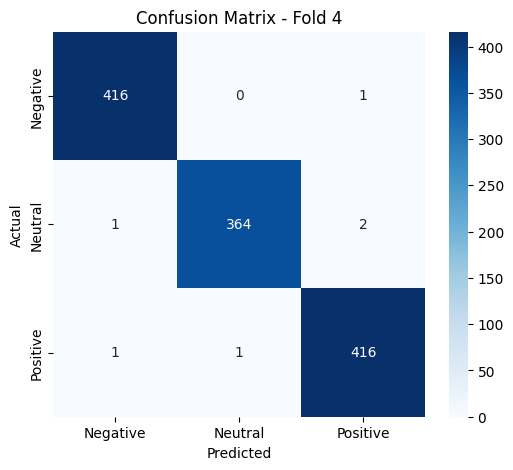


Misclassified Tweets:
Tweet: "Love is love. No matter who you are or who you love, you are valid, you are seen, and you are worthy.  #LGBTQ #Pride #LoveWins" | True: 0 | Predicted: 2
Tweet: "Sacrifices are symbolic acts of devotion and must be seen in the right context." | True: 2 | Predicted: 0
Tweet: "Leaving India for personal gain is selfish. Nation first!" | True: 1 | Predicted: 0
Tweet: "Purity of our national character is at stake when educated elites abandon India." | True: 1 | Predicted: 2
Tweet: "Patriotism is about growthâwhether at home or abroad, contribute to Indiaâs rise!" | True: 1 | Predicted: 2

Fold 5/5


Epoch,Training Loss,Validation Loss
1,0.067700,0.081831
2,0.003000,0.023629
3,0.014600,0.002399


Fold 5 - Accuracy: 0.9983, Precision: 0.9983, Recall: 0.9983, F1-score: 0.9983
🔹 Misclassifications per Class (Actual → Predicted):
[[0 0 0]
 [0 0 0]
 [0 2 0]]


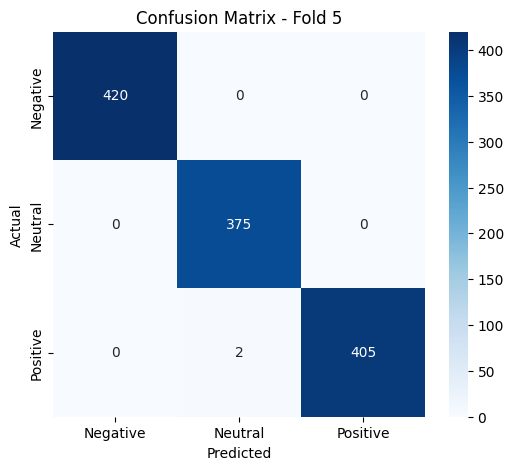


Misclassified Tweets:
Tweet: "True loyalty to one's faith must be safeguarded against coercion. #FaithFirst" | True: 2 | Predicted: 1
Tweet: "True purity of law means upholding justice for all, not selective inclusion." | True: 2 | Predicted: 1

Final Results Across 5 Folds:
Avg Loss: 0.0317
Avg Accuracy: 0.9894
Avg Precision: 0.9894
Avg Recall: 0.9894
Avg F1-Score: 0.9894


In [ ]:
# Perform K-Fold Cross-Validation on training data
k_fold_cross_validation(model, bert_train_dataset, k=5, batch_size=8, epochs=3, lr=2e-5, texts = text)

In [ ]:
evaluate_on_test(model, bert_test_dataset, batch_size=8)

# Tfidf with lstm
- The data set is limited(1207 Tweets).
- Data encoded using TF-IDF vectorizer and fed to lstm for classification
- Performing K(5 here) fold cross validation for analyzing the model

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels, vectorizer):
        self.sequences = vectorizer.transform(sequences).toarray()  # Transform text to numerical features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'features': torch.tensor(self.sequences[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMClassifier, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, batch_first=True,bidirectional = True)

        self.hidden1 = nn.Linear(hidden_dim*2, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.hidden3 = nn.Linear(64, 32)
        self.classifier = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
      # Reshape input to (batch_size, sequence_length=1, input_size)
      x = x.unsqueeze(1)
      _, (hidden, _) = self.bilstm(x)
      hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # Concatenate the last two hidden states
      #output = self.dropout(hidden[-1])
      output = self.hidden1(hidden)
      output = self.dropout(output)
      output = self.hidden2(output)
      output = self.dropout(output)
      output = self.hidden3(output)
      output = self.dropout(output)
      return self.classifier(output)

In [ ]:
def k_fold_cross_validation(model, dataset, texts, labels, k=5, batch_size=8, epochs=5, lr=1e-3):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold+1}/{k}")

        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)

        train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
        val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)

        for epoch in range(epochs):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()

                features = batch['features'].to(device)
                labels = batch['label'].to(device)

                outputs = model(features)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            scheduler.step()
            # model_path = f"./saved_models/bilstm/fold{fold+1}.pt"
            # torch.save(model.state_dict(), model_path)
            # print(f"Model for Fold {fold+1} saved to {model_path}")

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                features = batch['features'].to(device)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch['label'].cpu().numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix for Fold {fold+1}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")


In [ ]:
vectorizer = TfidfVectorizer(max_features=512)
features = vectorizer.fit_transform(X).toarray()
vocab = vectorizer.get_feature_names_out()

In [ ]:
input_dim = features.shape[1]
hidden_dim = 256
output_dim = 3

In [ ]:
print(input_dim)

512


In [ ]:
dataset = SentimentDataset(X, y, vectorizer)

In [ ]:
model = LSTMClassifier(input_dim, hidden_dim, output_dim)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMClassifier(
  (bilstm): LSTM(512, 256, batch_first=True, bidirectional=True)
  (hidden1): Linear(in_features=512, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (classifier): Linear(in_features=32, out_features=3, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


Fold 1/5
Fold 1 - Accuracy: 0.6908, Precision: 0.6915, Recall: 0.6908, F1-score: 0.6902


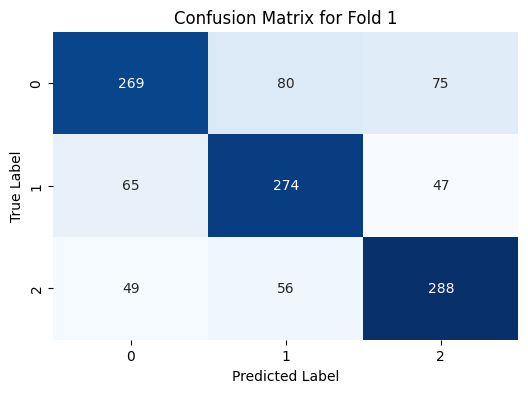


Fold 2/5
Fold 2 - Accuracy: 0.7571, Precision: 0.7578, Recall: 0.7571, F1-score: 0.7572


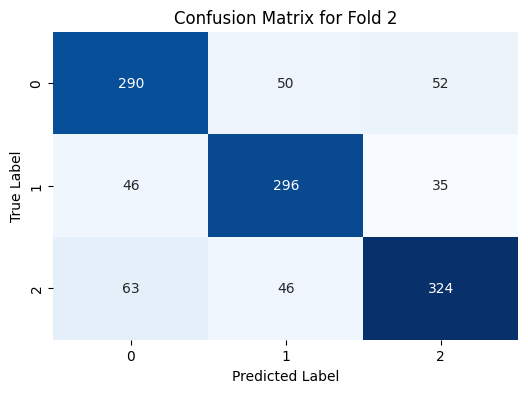


Fold 3/5
Fold 3 - Accuracy: 0.8203, Precision: 0.8229, Recall: 0.8203, F1-score: 0.8201


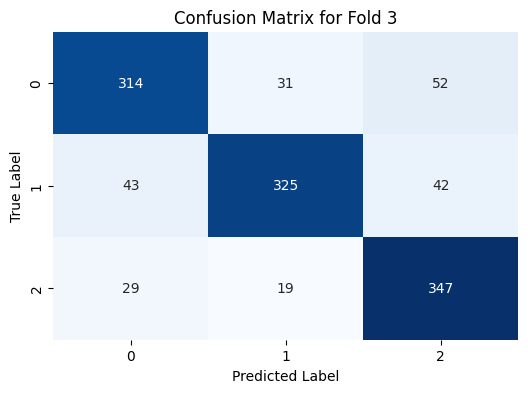


Fold 4/5
Fold 4 - Accuracy: 0.8020, Precision: 0.8033, Recall: 0.8020, F1-score: 0.8022


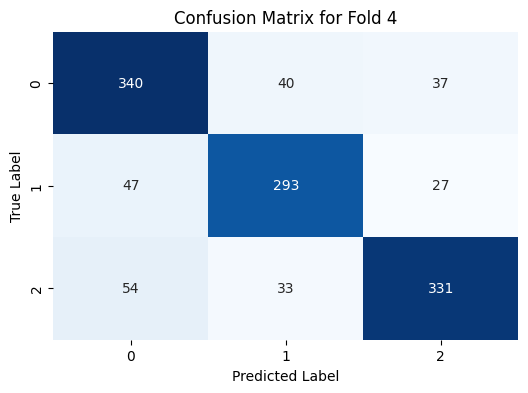


Fold 5/5
Fold 5 - Accuracy: 0.8303, Precision: 0.8322, Recall: 0.8303, F1-score: 0.8307


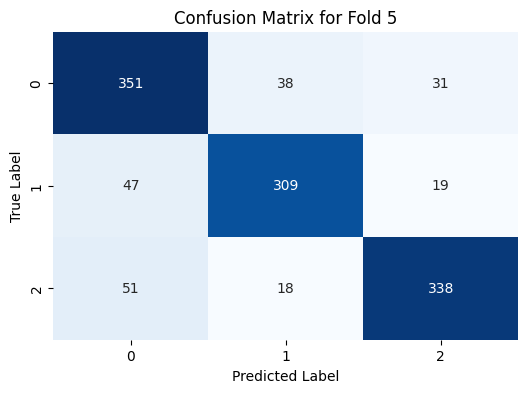


Final Results Across 5 Folds:
Avg Accuracy: 0.7801
Avg Precision: 0.7815
Avg Recall: 0.7801
Avg F1-Score: 0.7801


In [ ]:
k_fold_cross_validation(model, dataset, X, y)

In [ ]:
!zip -r results.zip ./results

  adding: results/ (stored 0%)
  adding: results/fold3/ (stored 0%)
  adding: results/fold3/checkpoint-752/ (stored 0%)
  adding: results/fold3/checkpoint-752/trainer_state.json (deflated 66%)
  adding: results/fold3/checkpoint-752/config.json (deflated 50%)
  adding: results/fold3/checkpoint-752/scheduler.pt (deflated 55%)
  adding: results/fold3/checkpoint-752/optimizer.pt (deflated 25%)
  adding: results/fold3/checkpoint-752/rng_state.pth (deflated 25%)
  adding: results/fold3/checkpoint-752/training_args.bin (deflated 52%)
  adding: results/fold3/checkpoint-752/model.safetensors (deflated 7%)
  adding: results/fold3/checkpoint-1504/ (stored 0%)
  adding: results/fold3/checkpoint-1504/trainer_state.json (deflated 72%)
  adding: results/fold3/checkpoint-1504/config.json (deflated 50%)
  adding: results/fold3/checkpoint-1504/scheduler.pt (deflated 55%)
  adding: results/fold3/checkpoint-1504/optimizer.pt (deflated 25%)
  adding: results/fold3/checkpoint-1504/rng_state.pth (deflated 25

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=3, num_layers=1, dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # bi-directional
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        _, h_n = self.gru(x)
        h_n = torch.cat((h_n[-2], h_n[-1]), dim=1)
        out = self.dropout(h_n)
        return self.fc(out)


In [ ]:
def load_glove_embeddings(filepath, embedding_dim=300):
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings


In [ ]:
def sentence_to_embedding(sentence, word_to_vec, max_len=50, emb_dim=300):
    tokens = sentence.lower().split()
    embeddings = []

    for token in tokens[:max_len]:
        embeddings.append(word_to_vec.get(token, np.zeros(emb_dim)))
    while len(embeddings) < max_len:
        embeddings.append(np.zeros(emb_dim))

    return np.array(embeddings)

In [ ]:
def prepare_data(sentences, labels, word_to_vec, max_len=50, emb_dim=300):
    vectors = [sentence_to_embedding(s, word_to_vec, max_len, emb_dim) for s in sentences]
    return torch.tensor(np.stack(vectors)).float(), torch.tensor(labels)

In [ ]:
def k_fold_cross_validation(model, dataset, texts, labels, k=5, batch_size=8, epochs=5, lr=1e-3):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold+1}/{k}")

        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)

        train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
        val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)

        for epoch in range(epochs):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()

                features = batch['features'].to(device)
                labels = batch['label'].to(device)

                outputs = model(features)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            scheduler.step()
            model_path = f"./saved_models/bilstm/fold{fold+1}.pt"
            torch.save(model.state_dict(), model_path)
            print(f"Model for Fold {fold+1} saved to {model_path}")

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                features = batch['features'].to(device)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch['label'].cpu().numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix for Fold {fold+1}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()

    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")


In [6]:
import os
import requests
import zipfile

def download_glove(destination_folder="glove"):
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = os.path.join(destination_folder, "glove.6B.zip")
    glove_txt_path = os.path.join(destination_folder, "glove.6B.300d.txt")

    os.makedirs(destination_folder, exist_ok=True)

    if not os.path.exists(glove_txt_path):
        print("Downloading GloVe embeddings...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        print("Extracting GloVe embeddings...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)

        os.remove(zip_path)  # Clean up the zip file
        print("GloVe embeddings downloaded and extracted.")
    else:
        print("GloVe embeddings already exist.")

# Run the function
download_glove()

Extracting GloVe embeddings...
GloVe embeddings downloaded and extracted.


In [ ]:
word_to_vec = load_glove_embeddings("/content/glove/glove.6B.300d.txt")



In [ ]:
label_encoder = LabelEncoder()
label_list = label_encoder.fit_transform(y)
# Prepare data
X_tensor, y_tensor = prepare_data(X, label_list, word_to_vec)


Fold 1/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8842
 Epoch 2 - Loss: 0.6651
 Epoch 3 - Loss: 0.5372
Fold 1 - Accuracy: 0.7381, Precision: 0.7548, Recall: 0.7381, F1: 0.7383


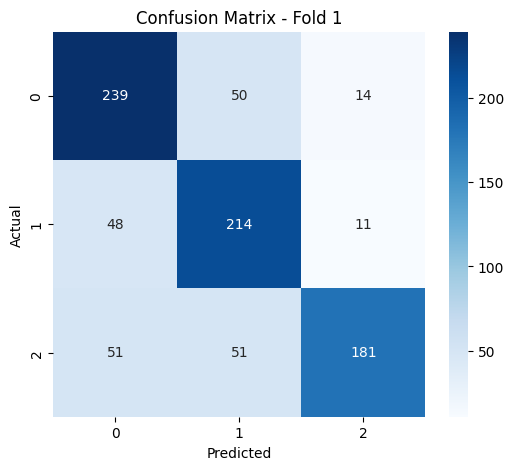


Misclassified Tweets:
 Tweet: "In the freezing cold of December, the women of Shaheen bagh keep vigil under blankets, their infants in a huddle under one arm, as men distribute chai and boiled eggs. It's 17th night of this women led vigil against #CAA #NRC. The Tiranga is at the centre #ShaheenBagh" | True: 0 | Predicted: 1
 Tweet: "Modi himself raised serious concern about EVM during the 2014 LS election. What happened to his stand now ? Will the media share this clip to Modi ask his stand ?@narendramodi #EVM" | True: 0 | Predicted: 1
 Tweet: "Retired IAS #Kannan_Gopinathan  tells u why it's necessary to ban #EVM's.Earlier, by pressing the button of #EVM, vote went directly to the CU & now #VVPAT is  in between.
Vote rigging happens in the VVPAT only. Why is the SC  not banning #EVM's ?" | True: 1 | Predicted: 0
 Tweet: "The #EVM scam !Why should it be treated as a holy black box ? We need openness and transparency" | True: 2 | Predicted: 1
 Tweet: "In my POV, If BJP could really man

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8875
 Epoch 2 - Loss: 0.6641
 Epoch 3 - Loss: 0.5284
Fold 2 - Accuracy: 0.7264, Precision: 0.7357, Recall: 0.7264, F1: 0.7255


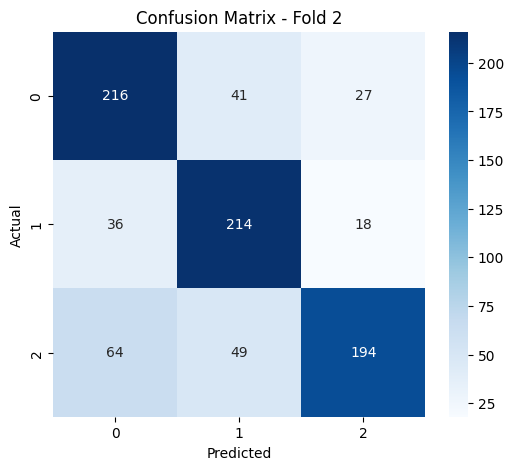


Misclassified Tweets:
 Tweet: "Kapil Mishra, BJP on violence in North East Delhi: I appeal to everyone to stop violence as it will not lead to any solution. Whether it is people who are supporting #CAA or those who are against it, I appeal everyone to maintain peace. Delhi's brotherhood should remain intact." | True: 1 | Predicted: 0
 Tweet: "Ã¢ÂÂBJPÃ¢ÂÂs vision, only televisionÃ¢ÂÂ.... so now they are claiming & dreaming to rule for the next 50 years... seems like they have full confidence in their EVM strategy, that is, Election Via Mischief. *#EVM #ElectionViaMischief*" | True: 1 | Predicted: 0
 Tweet: "Anyone spreading fake news and rumors about #CAA will face strict legal action. This law doesn't revoke anyone's citizenship, and it isn't against any religion or faith.

Be a responsible citizen, know the truth, and beware of fake news." | True: 1 | Predicted: 2
 Tweet: "Occupying PoK is a fancy idea but what about PoK Muslims? 

We canÃ¢ÂÂt give them citizenship now as #CA

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8835
 Epoch 2 - Loss: 0.6625
 Epoch 3 - Loss: 0.5290
Fold 3 - Accuracy: 0.7148, Precision: 0.7486, Recall: 0.7148, F1: 0.7149


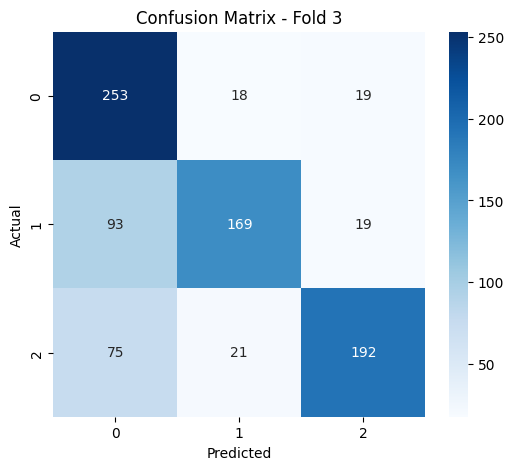


Misclassified Tweets:
 Tweet: "Ppl standing in Rain to welcome PM Modi in kerala. Then the lobby questions #ModiMagic to #EVM ." | True: 0 | Predicted: 2
 Tweet: "At this rate, soon #EVM's will be on Amazon and Flipkart." | True: 0 | Predicted: 1
 Tweet: "If you win, Democracy wins. But If you loose, Blame EVMs. BJP @BJP4India has never raised concerns about the reliability of EVMs or questioned the integrity of the Election Commission of India. 
@ECISVEEP #EVM" | True: 2 | Predicted: 1
 Tweet: "Law Commission extends deadline till July 28 for public to send views on uniform civil code.

#Uniform_Civil_Code #lawcommission" | True: 1 | Predicted: 0
 Tweet: "Discrimination is major factor affecting trans+ peopleÃ¢ÂÂs mental health, says study" | True: 1 | Predicted: 0

Fold 4/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8879
 Epoch 2 - Loss: 0.6735
 Epoch 3 - Loss: 0.5422
Fold 4 - Accuracy: 0.7206, Precision: 0.7436, Recall: 0.7206, F1: 0.7207


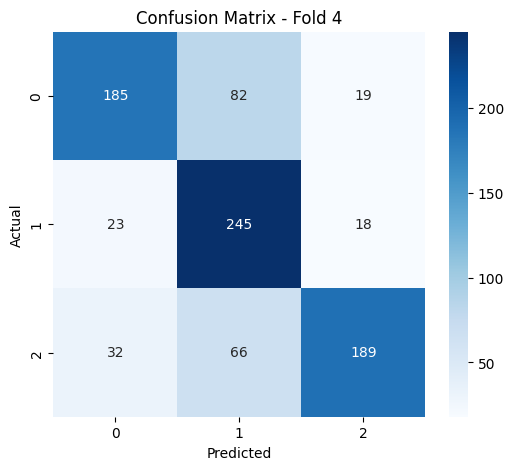


Misclassified Tweets:
 Tweet: "#EVMs are easy to manipulate . This was demonstrated by the #BJP in 2009 !" | True: 0 | Predicted: 1
 Tweet: "Madhya Pradesh: A protestor pulls hair of Rajgarh Deputy Collector Priya Verma, after she hits BJP workers and drags them. The clash broke out during a demonstration in support of #CAA." | True: 1 | Predicted: 0
 Tweet: "#CAA is meant to provide fast track citizenship to non-Muslim families from Afghanistan, Pakistan and Bangladesh that have been lynched, raped and persecuted for generations due to their religious beliefs. 

Whatever side youÃ¢ÂÂre on, make sure itÃ¢ÂÂs the compassionate one." | True: 1 | Predicted: 2
 Tweet: "Reply to #KhanSir on #Uniform_Civil_Code 

#UCCDividesIndia" | True: 0 | Predicted: 2
 Tweet: "Love how 
@narendramodi
 has everyone guessing about the exact purpose of the special session of the parliament. Lots of decoys abound though, #UCC, #OneNationOneEducation #Bharat but no one knows exactly what is coming :)" | 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8831
 Epoch 2 - Loss: 0.6664
 Epoch 3 - Loss: 0.5365
Fold 5 - Accuracy: 0.7125, Precision: 0.7141, Recall: 0.7125, F1: 0.7114


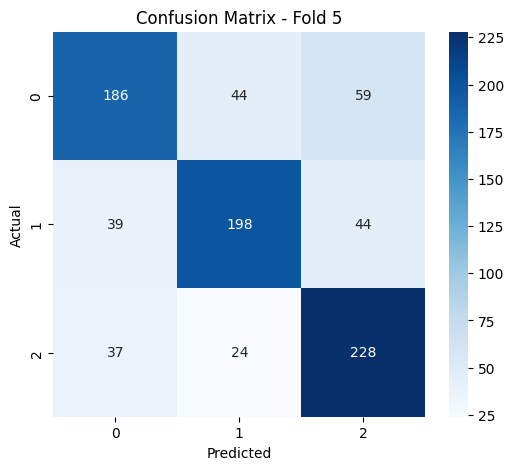


Misclassified Tweets:
 Tweet: "Congress leader Mani Shankar Aiyar at the protest against #CAA & #NRC, in Delhi's Shaheen Bagh" | True: 1 | Predicted: 2
 Tweet: "Students have contacted us from Jyoti Nivas college in Bangalore and told us they were threatened to support #CAA or "face consequences like JNU"- this happened outside their college gates. Hope relevant authorities are taking note" | True: 0 | Predicted: 2
 Tweet: "Vote rigging takes place in VVPAT also.Many organizations, intellectuals, lawyers are raising voice to ban #EVM. 
Even honest officers are resigning, still why is the Supreme Court not banning #EVM?" | True: 1 | Predicted: 0
 Tweet: "#HTEditorial | It may well be time for a section of the #Opposition to abandon its tired rhetoric on #EVM manipulation." | True: 1 | Predicted: 0
 Tweet: "Today there is a BIG protest by Muslims and their supporters against #CAA in August Kranti Maidan, from 3 to 8 pm. Pl. alert all your relatives and closed ones. Request all to stay a

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8862
 Epoch 2 - Loss: 0.6714
 Epoch 3 - Loss: 0.5471
Fold 6 - Accuracy: 0.7366, Precision: 0.7372, Recall: 0.7366, F1: 0.7368


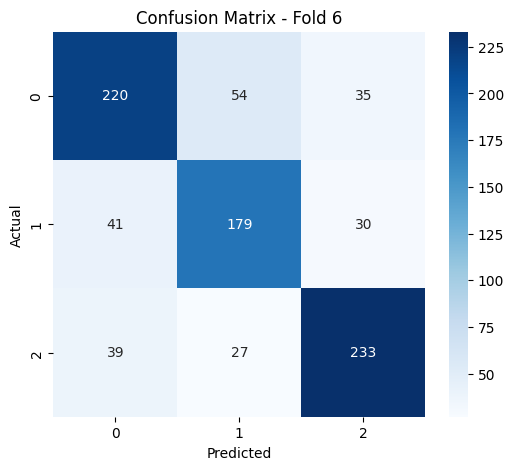


Misclassified Tweets:
 Tweet: "This guy was part of anti Hindu protests in the name of #CAA in which many Hindus were kiIIed.

Today he's enjoying celebrity life!!!!" | True: 1 | Predicted: 0
 Tweet: "So its Clear now Protest against #CAA is not for Political/Democratic Reason it's Ghazwa-E-Hind,Anti Hindu and Pure Fanatic Islamic Movement." | True: 2 | Predicted: 0
 Tweet: "When are they going to blame #EVM?#ElectionResults #VictoryForEknathSinde #Mahayuti" | True: 2 | Predicted: 0
 Tweet: "There is need for nationwide implementation of Uniform Civil Code (UCC) & One Nation One Election concept : CM Sawant" | True: 1 | Predicted: 2
 Tweet: "EVMs : EVMs Cheating Indian Democracy Shocking 
#EknathShinde
#Maharashtra #EVM #BanEVM" | True: 1 | Predicted: 2

Fold 7/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 0.8906
 Epoch 2 - Loss: 0.6707
 Epoch 3 - Loss: 0.5438
Fold 7 - Accuracy: 0.7564, Precision: 0.7694, Recall: 0.7564, F1: 0.7562


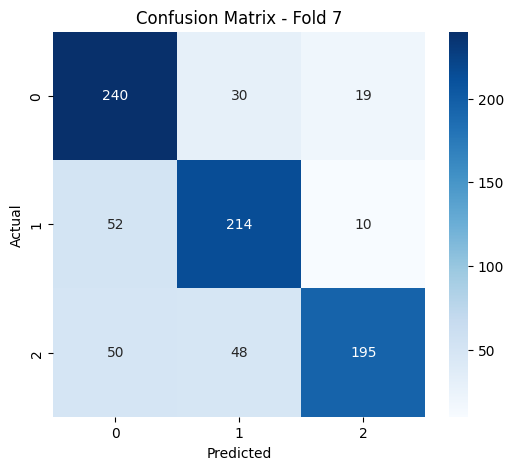


Misclassified Tweets:
 Tweet: "Meanwhile the Shiv Sena still doesnÃ¢ÂÂt know what #CAA is all about 
They are just toeing what Ã¢ÂÂSonia AmmaÃ¢ÂÂ says them to toe " | True: 2 | Predicted: 1
 Tweet: "Leftist Propaganda Portal The Wire spreads fake news on Ã¢ÂÂmismatchedÃ¢ÂÂ voters count in Maharashtra elections, but later deletes it when the Chief electoral officer of Maharashtra exposes them #EVM #MaharashtraElection2024" | True: 1 | Predicted: 0
 Tweet: "If women could stand to pee, why isn't there urinals in the women's bathroom too?" | True: 1 | Predicted: 0
 Tweet: "The "trans" womanface cosplayers who have hijacked gender for their sick perversions are 100% the people who everyone in MAGA/MAHA has issues with. 

It's entirely shameful that the crazy Left enables them & makes life harder for people with actual gender dysphoria." | True: 0 | Predicted: 2
 Tweet: "In a world that tries to erase us, every moment of love, laughter, and authenticity is a revolution. Keep exis

In [ ]:
k_fold_gru_cross_validation(
    model_class=GRUClassifier,
    X=X_tensor,
    y=y_tensor,
    texts=X,
    label_encoder=label_encoder,
    output_dim=len(label_encoder.classes_)
)

#TFIDF with GRU

In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)



In [ ]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X).toarray()



In [ ]:
# Reshape TF-IDF into pseudo-sequence format
timesteps = 10
features_per_step = X_tfidf.shape[1] // timesteps
X_seq = X_tfidf[:, :timesteps * features_per_step].reshape(-1, timesteps, features_per_step)



In [ ]:
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)



In [ ]:
# 2. Define GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_dim):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n.squeeze(0))

# 3. K-Fold Cross Validation



In [ ]:
GRU_2_losses,GRU_2_accuracies,GRU_2_precisions,GRU_2_recalls,GRU_2_f1_scores = [],[],[],[],[]

In [ ]:
def k_fold_gru_cross_validation(model_class, X, y, texts, label_encoder, output_dim,
                                 k=7, batch_size=16, epochs=3, lr=1e-3):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    losses, accuracies, precisions, recalls, f1_scores = [], [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold+1}/{k}")

        # Data subsets
        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        val_dataset = TensorDataset(X[val_idx], y[val_idx])

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        # Model setup
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model_class(input_size=X.shape[2], hidden_size=64, output_dim=output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Training
        model.train()
        for epoch in range(epochs):
            epoch_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            print(f" Epoch {epoch+1} - Loss: {epoch_loss / len(train_loader):.4f}")

        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        misclassified_samples = []

        with torch.no_grad():
            for i, (xb, yb) in enumerate(val_loader):
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                predicted = torch.argmax(preds, dim=1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())

                for j, (pred, true) in enumerate(zip(predicted, yb)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[i * batch_size + j]], true.item(), pred.item()))

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
        GRU_2_accuracies.append(acc)
        GRU_2_precisions.append(prec)
        GRU_2_recalls.append(rec)
        GRU_2_f1_scores.append(f1)
        GRU_2_losses.append(epoch_loss)
        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:
            print(f" Tweet: \"{text}\" | True: {true} | Predicted: {pred}")

    # Final Results
    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")




Fold 1/7
 Epoch 1 - Loss: 1.0821
 Epoch 2 - Loss: 0.8753
 Epoch 3 - Loss: 0.6742
Fold 1 - Accuracy: 0.6624, Precision: 0.6632, Recall: 0.6624, F1: 0.6607


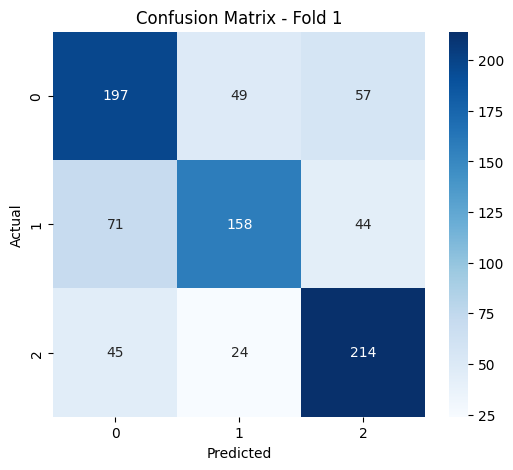


Misclassified Tweets:
 Tweet: "Modi himself raised serious concern about EVM during the 2014 LS election. What happened to his stand now ? Will the media share this clip to Modi ask his stand ?@narendramodi #EVM" | True: 0 | Predicted: 2
 Tweet: "The #EVM scam !Why should it be treated as a holy black box ? We need openness and transparency" | True: 2 | Predicted: 0
 Tweet: "In my POV, If BJP could really manipulate  #EVM, they would have never let go #Karnataka and definitely took #Bengal  Agree?" | True: 2 | Predicted: 1
 Tweet: "I have spent about 60 years in the forefront of #electronics, #telecom,IT, #software, #complex systems and a lot more. I have studied #EVM system carefully and believe that it is possible to manipulate. The best approach is the traditional paper ballet to count as casted." | True: 0 | Predicted: 1
 Tweet: "Bengaluru Church organising protest against #CAA which allows oppressed Christians to get Indian citizenship..

What to say!!!" | True: 1 | Predicted: 0


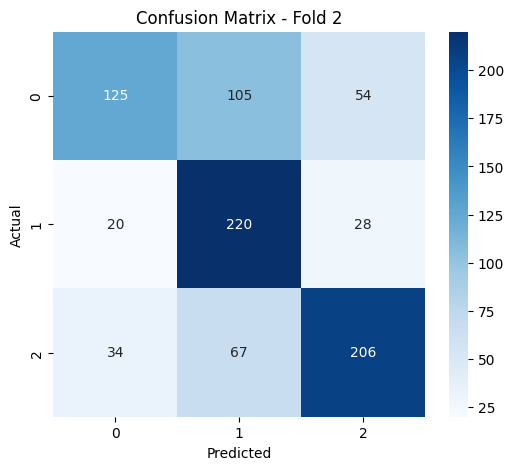


Misclassified Tweets:
 Tweet: "Kapil Mishra, BJP on violence in North East Delhi: I appeal to everyone to stop violence as it will not lead to any solution. Whether it is people who are supporting #CAA or those who are against it, I appeal everyone to maintain peace. Delhi's brotherhood should remain intact." | True: 1 | Predicted: 2
 Tweet: "#EVM is cheating with voters, with democracy. Paper ballot is only transparent way #BanEVM" | True: 0 | Predicted: 1
 Tweet: "Occupying PoK is a fancy idea but what about PoK Muslims? 

We canÃ¢ÂÂt give them citizenship now as #CAA is already in force." | True: 1 | Predicted: 0
 Tweet: "Don't ask who I am 

#uniform_civil_code 
No Caste based reservations" | True: 2 | Predicted: 1
 Tweet: "I'm surprised  to know that 
@HMOIndia
 & Law Ministry is opposing the PIL of 
@AshwiniBJP
 on #Uniform_Civil_Code though #UCC is integral part of BJP's Manifesto since its birth.
" | True: 1 | Predicted: 2

Fold 3/7
 Epoch 1 - Loss: 1.0768
 Epoch 2 - Loss: 0

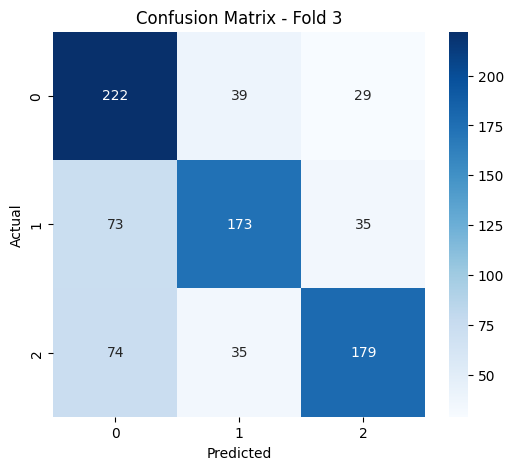


Misclassified Tweets:
 Tweet: "Big difference between booth capturing and EVM fraud: Booth capturing can be caught and fixed. EVM fraud can go unnoticed and can't be solved #EVM" | True: 1 | Predicted: 2
 Tweet: "If you win, Democracy wins. But If you loose, Blame EVMs. BJP @BJP4India has never raised concerns about the reliability of EVMs or questioned the integrity of the Election Commission of India. 
@ECISVEEP #EVM" | True: 2 | Predicted: 1
 Tweet: "Prime Minister 
@narendramodi
 angrily says there has been no talk of nationwide NRC except Supreme Court mandated #NRC in Assam. But this sir is not true. The Home Minister has clearly referenced it. All you need to say is that there is NO NRC for India #CAA #NRC #RamlilaMaidan" | True: 1 | Predicted: 0
 Tweet: "Does this Mor0n even understand what #CAA is?" | True: 1 | Predicted: 0
 Tweet: "Winning candidates in Nashik District Assembly constituencies have almost the same number of votes.

IsnÃ¢ÂÂt this strange but ECI wonÃ¢ÂÂt t

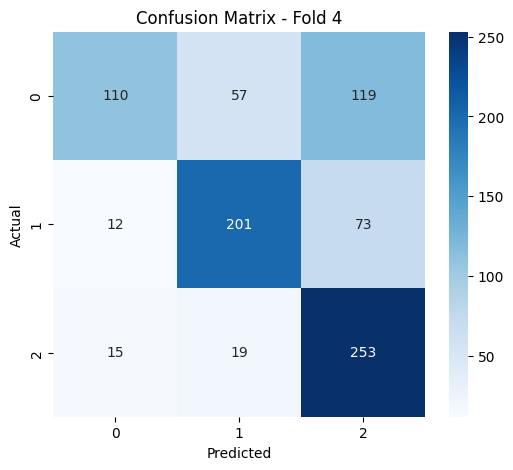


Misclassified Tweets:
 Tweet: "#EVMs are easy to manipulate . This was demonstrated by the #BJP in 2009 !" | True: 0 | Predicted: 2
 Tweet: "Delhi with #CAA
@narendramodi
 
Delhi with 
@AmitShah" | True: 2 | Predicted: 1
 Tweet: "#CAA is meant to provide fast track citizenship to non-Muslim families from Afghanistan, Pakistan and Bangladesh that have been lynched, raped and persecuted for generations due to their religious beliefs. 

Whatever side youÃ¢ÂÂre on, make sure itÃ¢ÂÂs the compassionate one." | True: 1 | Predicted: 0
 Tweet: "Dear Modi govt, withdraw present #CAA and if you must have it, redraft it substantially. Take out these words :Ã¢ÂÂHindu, Sikh, Buddhist, Jain, Parsi, Christian.Ã¢ÂÂ Replace with these words: Ã¢ÂÂpersecuted religious minorities.Ã¢ÂÂ Ã°ÂÂÂ#CAA_NRC_Protests" | True: 0 | Predicted: 2
 Tweet: "Reply to #KhanSir on #Uniform_Civil_Code 

#UCCDividesIndia" | True: 0 | Predicted: 2

Fold 5/7
 Epoch 1 - Loss: 1.0826
 Epoch 2 - Loss: 0.8577
 Epoch 

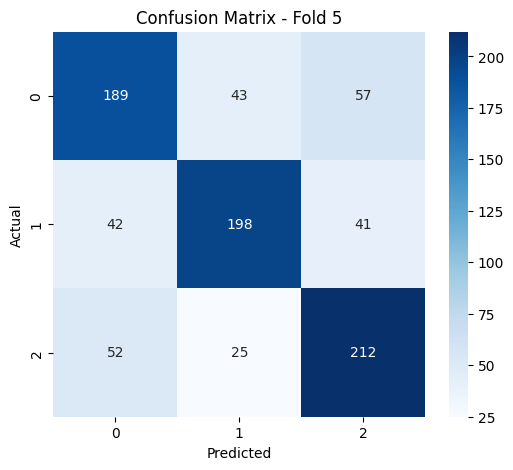


Misclassified Tweets:
 Tweet: "Congress leader Mani Shankar Aiyar at the protest against #CAA & #NRC, in Delhi's Shaheen Bagh" | True: 1 | Predicted: 0
 Tweet: "I strongly feel #Modi did use some Pegasus type of malware to manipulate #EVM during 2019 elections. " | True: 0 | Predicted: 1
 Tweet: "Broad daylight kidnapping of a girl in #BJP ruled #Rajasthan state Difficult to believe that the #BJP party enjoys popular mandates. Why would people ever vote for such rogues?
#EVM Manipulation?" | True: 1 | Predicted: 0
 Tweet: "Vote rigging takes place in VVPAT also.Many organizations, intellectuals, lawyers are raising voice to ban #EVM. 
Even honest officers are resigning, still why is the Supreme Court not banning #EVM?" | True: 1 | Predicted: 2
 Tweet: "#HTEditorial | It may well be time for a section of the #Opposition to abandon its tired rhetoric on #EVM manipulation." | True: 1 | Predicted: 0

Fold 6/7
 Epoch 1 - Loss: 1.0845
 Epoch 2 - Loss: 0.8486
 Epoch 3 - Loss: 0.6805
Fold 6 -

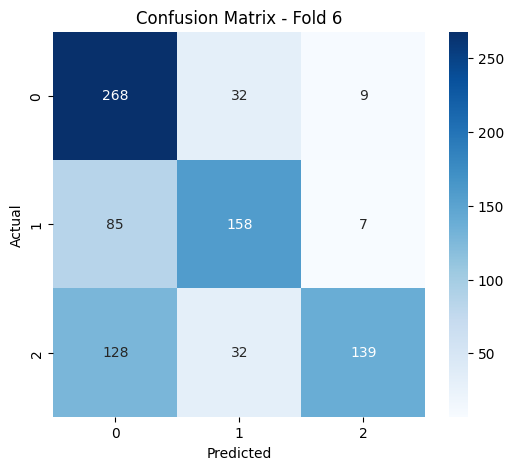


Misclassified Tweets:
 Tweet: "This guy was part of anti Hindu protests in the name of #CAA in which many Hindus were kiIIed.

Today he's enjoying celebrity life!!!!" | True: 1 | Predicted: 0
 Tweet: "The only person likely to believe all these #EVM hacking stories is Rahul Gandhi." | True: 2 | Predicted: 0
 Tweet: "When are they going to blame #EVM?#ElectionResults #VictoryForEknathSinde #Mahayuti" | True: 2 | Predicted: 0
 Tweet: "Interacted with students of 
@iimtnoida
 in morning. Must Say Youth is well informed about #CAA & fake narrative build around it ." | True: 1 | Predicted: 0
 Tweet: "Aslam from Bhopal canÃ¢ÂÂt read/speak English. DoesnÃ¢ÂÂt read newspapers. DoesnÃ¢ÂÂt know what #CAA stands for. DoesnÃ¢ÂÂt know if Assam is in East or West. He is a Bollywood fan.

Now he opposes #CAA #NRC and burning tyres as protest because Farhan Akhtar & Alia Bhatt have opposed it." | True: 2 | Predicted: 0

Fold 7/7
 Epoch 1 - Loss: 1.0789
 Epoch 2 - Loss: 0.8618
 Epoch 3 - Loss:

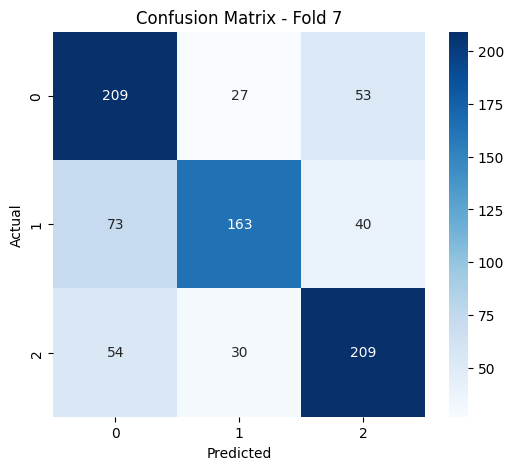


Misclassified Tweets:
 Tweet: "Meanwhile the Shiv Sena still doesnÃ¢ÂÂt know what #CAA is all about 
They are just toeing what Ã¢ÂÂSonia AmmaÃ¢ÂÂ says them to toe " | True: 2 | Predicted: 1
 Tweet: "I will not provide documents for #CAA. 

Who is Amit Shah and Narendra Modi to determine my Indianness ? 

#CAB #CAA" | True: 0 | Predicted: 2
 Tweet: "Gender Identity Disorder was first set as a diagnosis in the Diagnostic Statistical Manual (used to diagnosis mental illnesses) in 1987. It was changed to Gender Dysphoria in 2013 to erase the stigma attached to the word Disorder. Note the prevalence rate. I wonder if some of those interesting studies have lapsed due to not wanting to find the biological, genetic, or psychological influences that may be causal and perhaps able to be addressed. Note the paragraph that advises the proper course of treatment to make sure the person is doing it for the right reason! And how much higher the success rate was. " | True: 1 | Predicted: 0
 Twe

In [ ]:
# Run the cross-validation
k_fold_gru_cross_validation(GRUModel, X_tensor, y_tensor, X, label_encoder, output_dim=num_classes)

# LSTM wiht GloVE embeddings

In [7]:
def load_glove_embeddings(glove_file_path, embedding_dim=300):
    word_to_vec = {}
    with open(glove_file_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            word_to_vec[word] = vector
    return word_to_vec


In [8]:
def sentence_to_embedding(sentence, word_to_vec, max_len=50, emb_dim=300):
    tokens = sentence.lower().split()
    embeddings = [word_to_vec.get(token, np.zeros(emb_dim)) for token in tokens[:max_len]]
    while len(embeddings) < max_len:
        embeddings.append(np.zeros(emb_dim))
    return np.array(embeddings)

In [9]:
def prepare_data(sentences, labels, word_to_vec, max_len=50, emb_dim=300):
    vectors = [sentence_to_embedding(s, word_to_vec, max_len, emb_dim) for s in sentences]
    return torch.tensor(np.stack(vectors)).float(), torch.tensor(labels)

In [10]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, output_dim)

    def forward(self, x):
        hidden, _ = self.lstm(x)
        hidden = hidden[:,-1,:]  # last hidden state
        x = self.dropout(hidden)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        return self.output(x)


In [16]:
def k_fold_lstm_cross_validation(model_class, X, y, texts,lr, label_encoder, output_dim,
                                 k=5, batch_size=8, epochs=3, hidden_dim=256, input_dim=300):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold+1}/{k}")

        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        val_dataset = TensorDataset(X[val_idx], y[val_idx])

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model_class(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.1)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
        # Training
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f" Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f}")
            scheduler.step()
        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        misclassified_samples = []

        with torch.no_grad():
            for i, (xb, yb) in enumerate(val_loader):
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                predicted = torch.argmax(preds, dim=1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
                for j, (pred, true) in enumerate(zip(predicted, yb)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[i * batch_size + j]], true.item(), pred.item()))

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:
            print(f" Tweet: \"{text}\" | True: {true} | Predicted: {pred}")

    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")

In [13]:
glove_path = "glove/glove.6B.300d.txt"

word_to_vec = load_glove_embeddings(glove_path, embedding_dim=300)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_tensor, y_tensor = prepare_data(X, y_encoded, word_to_vec, max_len=50, emb_dim=300)

In [14]:
print(X_tensor)

tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [-2.3589e-01,  3.8310e-01,  1.0834e-01,  ..., -7.9189e-01,
          -8.5960e-02, -1.4660e-01],
         [ 6.7032e-02, -1.0813e-01,  4.4981e-01,  ..., -1.5073e-01,
          -2.5662e-01,  8.0550e-02],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[-4.6278e-02, -4.4251e-01,  3.5330e-01,  ..., -3.2006e-01,
          -5.7408e-02, -1.0382e-01],
         [-2.3164e-01, -1.0817e-01,  8.9245e-01,  ..., -7.7543e-01,
           1.0500e-01, -3.4728e-01],
         [-1.7490e-01,  2.2956e-01,  2.4924e-01,  ..., -2.4131e-01,
          -4.0402e-01,  5.4744e-02],
         ...,
         [ 0.0000e+00,  0


Fold 1/5
 Epoch 1 - Loss: 1.0995
 Epoch 2 - Loss: 1.0987
 Epoch 3 - Loss: 1.0984
Fold 1 - Accuracy: 0.3525, Precision: 0.1242, Recall: 0.3525, F1: 0.1837


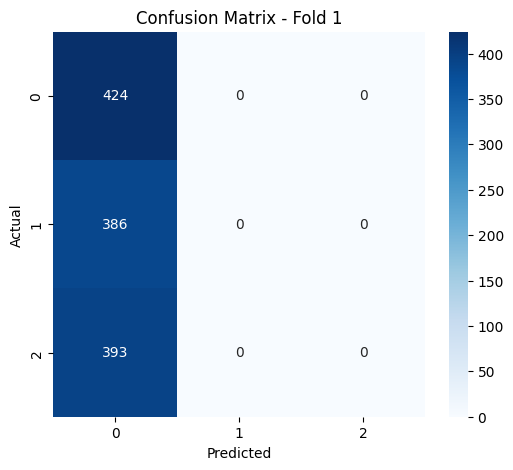


Misclassified Tweets:
 Tweet: "Retired IAS #Kannan_Gopinathan  tells u why it's necessary to ban #EVM's.Earlier, by pressing the button of #EVM, vote went directly to the CU & now #VVPAT is  in between.
Vote rigging happens in the VVPAT only. Why is the SC  not banning #EVM's ?" | True: 1 | Predicted: 0
 Tweet: "The #EVM scam !Why should it be treated as a holy black box ? We need openness and transparency" | True: 2 | Predicted: 0
 Tweet: "In my POV, If BJP could really manipulate  #EVM, they would have never let go #Karnataka and definitely took #Bengal  Agree?" | True: 2 | Predicted: 0
 Tweet: "Bengaluru Church organising protest against #CAA which allows oppressed Christians to get Indian citizenship..

What to say!!!" | True: 1 | Predicted: 0
 Tweet: "Competing priorities, political realities and delicate balancing between whatÃ¢ÂÂs immediately possible and what could potentially disrupt peace and progress made so far.

#CAA took a while, saw widespread protests and #ShaheenBag

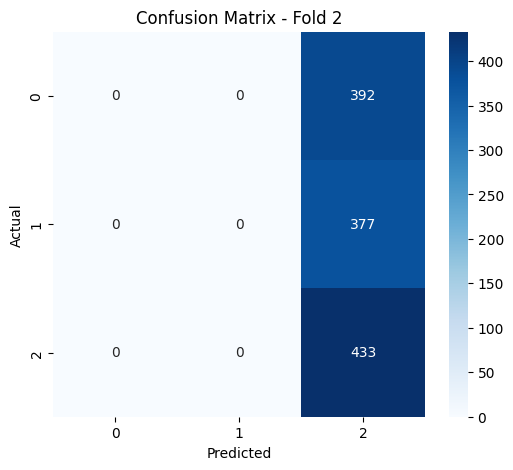


Misclassified Tweets:
 Tweet: "Kapil Mishra, BJP on violence in North East Delhi: I appeal to everyone to stop violence as it will not lead to any solution. Whether it is people who are supporting #CAA or those who are against it, I appeal everyone to maintain peace. Delhi's brotherhood should remain intact." | True: 1 | Predicted: 2
 Tweet: "Ppl standing in Rain to welcome PM Modi in kerala. Then the lobby questions #ModiMagic to #EVM ." | True: 0 | Predicted: 2
 Tweet: "At this rate, soon #EVM's will be on Amazon and Flipkart." | True: 0 | Predicted: 2
 Tweet: "Ã¢ÂÂBJPÃ¢ÂÂs vision, only televisionÃ¢ÂÂ.... so now they are claiming & dreaming to rule for the next 50 years... seems like they have full confidence in their EVM strategy, that is, Election Via Mischief. *#EVM #ElectionViaMischief*" | True: 1 | Predicted: 2
 Tweet: "Anyone spreading fake news and rumors about #CAA will face strict legal action. This law doesn't revoke anyone's citizenship, and it isn't against any rel

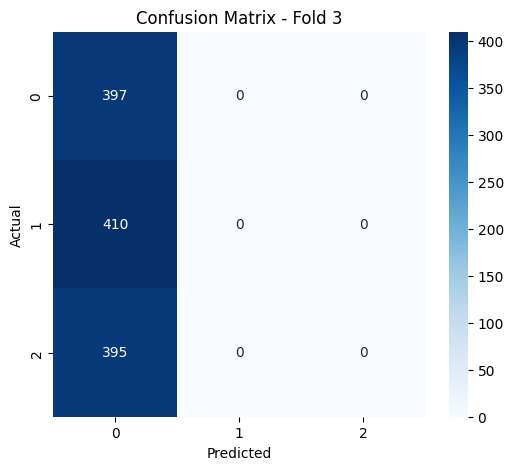


Misclassified Tweets:
 Tweet: "Delhi with #CAA
@narendramodi
 
Delhi with 
@AmitShah" | True: 2 | Predicted: 0
 Tweet: "Madhya Pradesh: A protestor pulls hair of Rajgarh Deputy Collector Priya Verma, after she hits BJP workers and drags them. The clash broke out during a demonstration in support of #CAA." | True: 1 | Predicted: 0
 Tweet: "We are raising our voice against the confusion surrounding #EVMs that has emerged among the people of the state." | True: 1 | Predicted: 0
 Tweet: "Broad daylight kidnapping of a girl in #BJP ruled #Rajasthan state Difficult to believe that the #BJP party enjoys popular mandates. Why would people ever vote for such rogues?
#EVM Manipulation?" | True: 1 | Predicted: 0
 Tweet: "Big difference between booth capturing and EVM fraud: Booth capturing can be caught and fixed. EVM fraud can go unnoticed and can't be solved #EVM" | True: 1 | Predicted: 0

Fold 4/5
 Epoch 1 - Loss: 1.1012
 Epoch 2 - Loss: 1.0992
 Epoch 3 - Loss: 1.0987
Fold 4 - Accuracy: 0.346

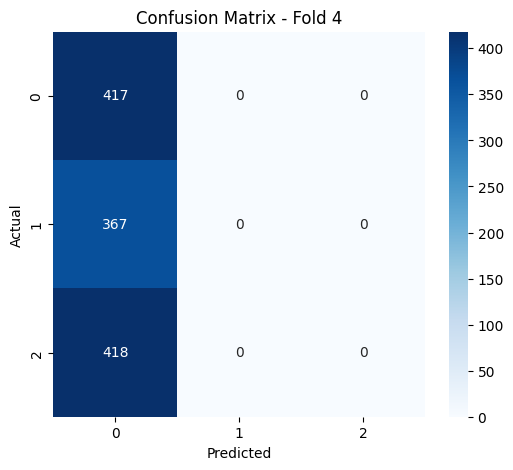


Misclassified Tweets:
 Tweet: "Congratulations
CAA  is arrived  #CAA" | True: 2 | Predicted: 0
 Tweet: "IÃ¢ÂÂm an Indian Muslim and I welcome #CAA" | True: 2 | Predicted: 0
 Tweet: "Congress leader Mani Shankar Aiyar at the protest against #CAA & #NRC, in Delhi's Shaheen Bagh" | True: 1 | Predicted: 0
 Tweet: "The only person likely to believe all these #EVM hacking stories is Rahul Gandhi." | True: 2 | Predicted: 0
 Tweet: "Vote rigging takes place in VVPAT also.Many organizations, intellectuals, lawyers are raising voice to ban #EVM. 
Even honest officers are resigning, still why is the Supreme Court not banning #EVM?" | True: 1 | Predicted: 0

Fold 5/5
 Epoch 1 - Loss: 1.1022
 Epoch 2 - Loss: 1.1003
 Epoch 3 - Loss: 1.0994
Fold 5 - Accuracy: 0.3120, Precision: 0.0973, Recall: 0.3120, F1: 0.1484


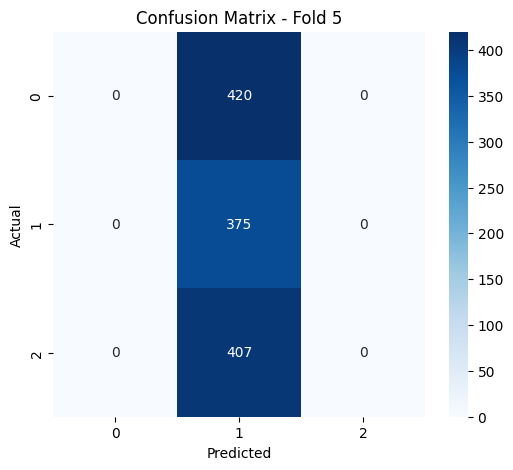


Misclassified Tweets:
 Tweet: "So its Clear now Protest against #CAA is not for Political/Democratic Reason it's Ghazwa-E-Hind,Anti Hindu and Pure Fanatic Islamic Movement." | True: 2 | Predicted: 1
 Tweet: "Meanwhile the Shiv Sena still doesnÃ¢ÂÂt know what #CAA is all about 
They are just toeing what Ã¢ÂÂSonia AmmaÃ¢ÂÂ says them to toe " | True: 2 | Predicted: 1
 Tweet: "I will not provide documents for #CAA. 

Who is Amit Shah and Narendra Modi to determine my Indianness ? 

#CAB #CAA" | True: 0 | Predicted: 1
 Tweet: "Join me in supporting the #Uniform_Civil_Code (UCC) for India's progress and unity! #OneNation_OneLaw will strengthen our diverse society, treating all citizens equally under a common legal framework. Let's rise above divisive influences and embrace this positive change." | True: 2 | Predicted: 1
 Tweet: "#UNIFORM_CIVIL_CODE
#ONE_NATION_ONE_LAW" | True: 2 | Predicted: 1

Final Results Across 5 Folds:
Avg Accuracy: 0.3404
Avg Precision: 0.1162
Avg Recall: 0.3404

In [17]:
k_fold_lstm_cross_validation(
    model_class=LSTMClassifier,
    X=X_tensor,
    y=y_tensor,
    texts=X,
    label_encoder=label_encoder,
    output_dim=len(label_encoder.classes_),
    k=5,
    batch_size=16,
    epochs=3,
    lr=5e-4,
    hidden_dim=256,
    input_dim=300
)